# CVZX Quick Start

`cvzx` is a compiler for continuous-variable (CV) quantum circuits, built on the CV-ZX calculus. This notebook is a short, hands-on tour of the core workflow:

1. **Build** a `Diagram` out of spiders and gates.
2. **Visualize** it.
3. **Convert** it to the graph representation the rewrite rules operate on.
4. **Simplify** it, first by hand (one rewrite rule at a time), then automatically via `optimize()`.

For a much deeper, physically-motivated worked example (building a gadget from scratch, running every rewrite rule by hand, and comparing against `optimize()`), see `example_1_measurement_induced_squeezer.ipynb` in this same folder.

In [1]:
from cvzx.ir.base import CompositionDiagram
from cvzx.ir.gates import PhaseRotationGate
from cvzx.backends.nx.graph import to_diagram, to_graph
from cvzx.backends.nx.rules import ChainReductionRule
from cvzx.passes.optimize import optimize
from cvzx.visualization.core import visualize

print("cvzx imported successfully.")

cvzx imported successfully.


## Building a diagram

A `Diagram` is built out of leaves (spiders and gates) combined with `CompositionDiagram` (sequential composition, causal left to right) and `TensorDiagram` (parallel composition, not used in this small example -- see `example_1`'s "Build the diagram" section for a worked case). Here we chain three phase rotations on a single mode:

In [2]:
theta1, theta2, theta3 = 0.3, 0.4, 0.5

rotation_chain = CompositionDiagram([
    PhaseRotationGate(theta1),
    PhaseRotationGate(theta2),
    PhaseRotationGate(theta3),
])

print(f"rotation_chain: {rotation_chain.num_inputs} input(s) -> {rotation_chain.num_outputs} output(s)")

rotation_chain: 1 input(s) -> 1 output(s)


Three separate `PhaseRotationGate`s composed in sequence are physically just one rotation by `theta1 + theta2 + theta3` -- but `cvzx` doesn't know that until a rewrite rule tells it so. Let's visualize the diagram as built, then simplify it.

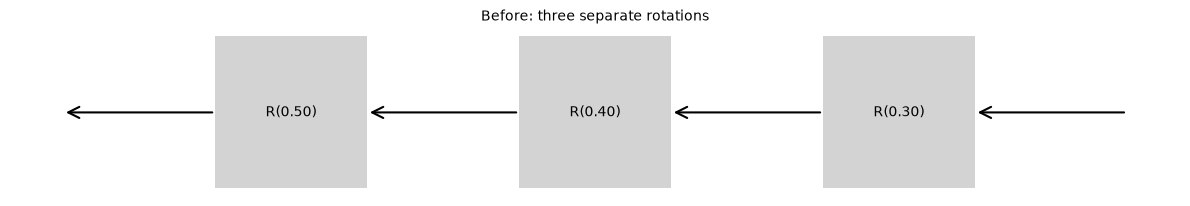

In [3]:
fig_before = visualize(rotation_chain, title="Before: three separate rotations")

## Converting to the graph representation

`to_graph`/`to_diagram` convert losslessly between a `Diagram` tree and its `networkx.DiGraph` form -- the representation every rewrite rule actually operates on. You will rarely need to call these directly (`optimize()`, below, does the conversion for you), but the graph is handy for inspecting a diagram's structure via its `GateRegister`, the index `RewriteRule.match()` uses to find candidate nodes quickly without re-scanning the whole graph.

In [4]:
graph = to_graph(rotation_chain)

print(f"nodes: {graph.graph.number_of_nodes()}, edges: {graph.graph.number_of_edges()}")
print("rotation gate node ids:", sorted(graph.registry.rotation_gates))

# Round-tripping through the graph and back is lossless.
assert to_diagram(graph) == rotation_chain

nodes: 4, edges: 2
rotation gate node ids: [1, 2, 3]


## Applying one rewrite rule by hand

`ChainReductionRule` fuses adjacent gates of the *same type* using their own algebraic composition law -- for `PhaseRotationGate`, that's simply adding the angles. Every rule works the same way: `rule.match(graph)` looks for its pattern (returning an empty list if nothing matches), and `rule.apply_rule(graph)` rewrites every match it finds, in place.

ChainReductionRule found 1 match(es)
Compose([PhaseRotationGate(theta=1.20), QSpider(num_imputs=1, num_outputs=1), QSpider(num_imputs=1, num_outputs=1)])


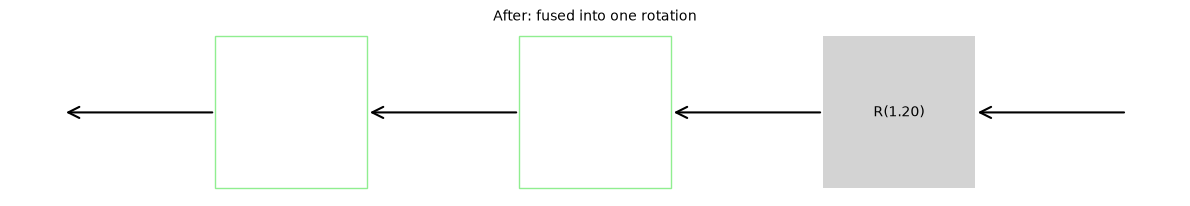

In [5]:
chain_reduction_rule = ChainReductionRule()

matches = chain_reduction_rule.match(graph)
print(f"ChainReductionRule found {len(matches)} match(es)")

chain_reduction_rule.apply_rule(graph)
fused = to_diagram(graph)

print(repr(fused))
fig_after = visualize(fused, title="After: fused into one rotation")

The three gates fused into a single `PhaseRotationGate(theta1 + theta2 + theta3)` -- plus two leftover identity-wire spiders that `ChainReductionRule` on its own doesn't clean up (that's `IdentityRule`'s job, part of the fixed sequence `optimize()` runs below). Hand-applying rules one at a time like this is useful for seeing what each rule does, but you'd rarely stop here in practice.

## The automated `optimize()` pipeline

In practice you would rarely apply rules by hand like above -- `optimize()` runs every rewrite rule (in a fixed order tuned so each one feeds the next) to a fixed point, and repeats that over multiple rounds, until nothing changes any more. It returns an `OptimizeResult` -- a `(graph, diagram)` named tuple: the cleaned `CVZXGraph`, and the `Diagram` as it stood right before the final cleanup pass (the one safe to visualize or hand to another tool).

PhaseRotationGate(theta=1.20)


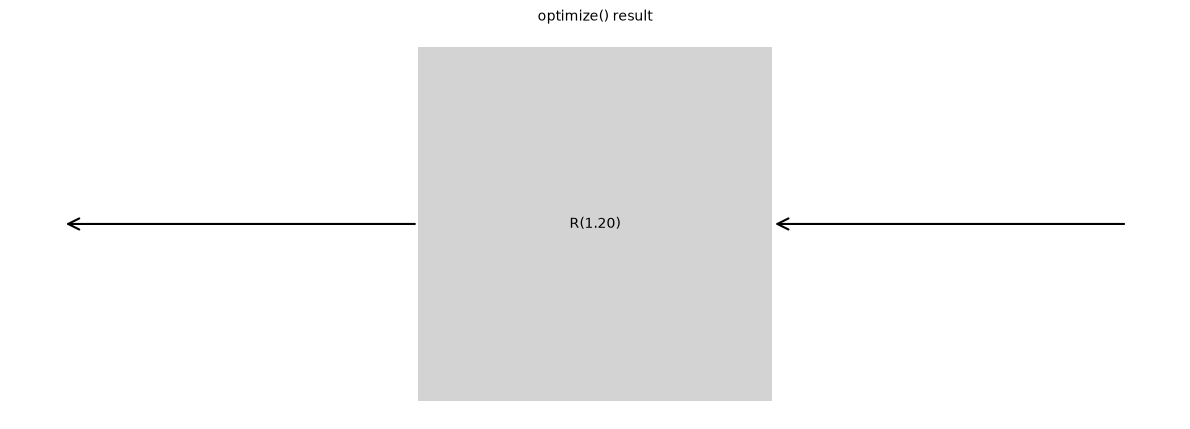

In [6]:
result = optimize(rotation_chain)

print(repr(result.diagram))
fig_optimized = visualize(result.diagram, title="optimize() result")

`optimize()` reaches the same fused rotation as above, but cleanly -- no leftover identity wires, since its fixed rule sequence includes `IdentityRule` and a final cleanup pass. For a diagram this small there's only one real simplification available either way, but for a real circuit `optimize()` is what lets rules feed each other across multiple rounds automatically (see `example_1_measurement_induced_squeezer.ipynb` for a case where the automated pipeline finds a smaller result than any single hand-applied pass).

## Where to go next

- `example_1_measurement_induced_squeezer.ipynb` (this folder): a full physically-motivated example, run rule by rule and compared against `optimize()`, plus a benchmarking section using `cvzx.utils.metrics`.

- The full Sphinx documentation (`docs/`, built via `python -m pip install -e ".[docs]" && cd docs && make html`) covers the theory mapping, every rewrite rule, converting to and from mqc3 circuits, and the complete API reference.

## Reference

This project builds on the continuous-variable ZX formalism introduced in:

> Hironari Nagayoshi, Warit Asavanant, Ryuhoh Ide, Kosuke Fukui, Atsushi Sakaguchi, Jun-ichi Yoshikawa, Nicolas C. Menicucci, and Akira Furusawa, “ZX graphical calculus for continuous-variable quantum processes,” *Physical Review Research* **7**, 033141 (2025). [arXiv:2405.07246](https://arxiv.org/abs/2405.07246)